 <center> <h1> <b> Pattern Recognition and Machine Learning (EE5610 - EE2802 - AI2000 - AI5000) </b> </h1> </center>

<b> Programming Assignment - 05 : Neural Networks </b>


In recent years, deep learning has become a cornerstone of modern artificial intelligence, powering applications ranging from speech recognition to computer vision. Despite the availability of high-level frameworks such as PyTorch and TensorFlow, a fundamental understanding of how neural networks operate internally remains essential for students. This assignment focuses on implementing a Feedforward Neural Network (FFN) from scratch using the MNIST dataset, a standard benchmark for handwritten digit classification. By avoiding automatic differentiation and built-in training utilities, students are required to manually construct the forward pass, compute loss functions, and derive and implement backpropagation. This hands-on approach bridges the gap between theoretical concepts and practical implementation, enabling students to develop a deeper intuition about optimization, gradient flow, and model behavior. Ultimately, this exercise aims to build a strong foundation that prepares students for advanced topics in machine learning and deep learning research.

<b> Instructions </b>
1. Plagiarism is strictly prohibited.
2. Please DO NOT use any machine learning libraries unless and otherwise specified.








<b>  Part - (1) : Develop a neural network based classification network from scratch: </b>  This programming assignment uses MNIST digit dataset. It consists of large collection of handwritten digits from 0 to 9. These images are formated as 28x28 pixel gray scale images. The objective of this programming assignment is to design a neural network architecture that takes input as 28x28 image (or 784 dimensional vector) as input and predicts the digit information in it. Although there are diffrent varieties of neural network architecture to solve this task, this programming assignment uses only the feed forward network.  

<dt> <h6> 1. Load MNIST data and create train, test splits </dt> </h6>

<dd> <h6> - The MNIST dataset consists of around 70,000 images. 60,000 images for training and 10,000 images for testing. Create a subsets of 10000 images for training, 1000 images for validation from training partition. create a subset of 1000 images for testing from testing partition.

</dd> </h6>
<dd> <h6> - Code for downloading the data and creating train-test splits is provided </dd> </h6>

<dt> <h6> 2. Design a simple classification network </dt> </h6>

<dd> <h6> - Let us use three layer feed-forward neral network. Use 512 nodes in the hidden layers and 10 nodes in the output layer. The output $\textbf{y}$ from the input $\textbf{x}$ is computed as follows </dd> </h6>
<dd> <h6> <center> $ \textbf{y} = h(\textbf{W}_{3}g(\textbf{W}_{2}g(\textbf{W}_{1}\textbf{x}))) $ </center> </dd> </h6>
<dd> <h6> where $\textbf{W}_{1} \in \mathcal{R}^{512 \times 768}$,$\textbf{W}_{2} \in \mathcal{R}^{512 \times 512}$,$\textbf{W}_{3} \in \mathcal{R}^{10 \times 512} $ are the parameters of the network. g(.) is the hidden layer activation function. h(.) is the output layer activation function   </dd> </h6>
<dd> <h6> - Consider g(.) as ReLU activation function. Softmax activation function should be used at the last layer h(.), to get the posterior probability of the classes. </dd> </h6>

<dt> <h6> - Training classification network: </dt> </h6>

<dd> <h6>  - Flatten the 28x28 images to arrive at 784 dimensional vector.  </dd> </h6>  
<dd> <h6> - Randomly initialize the parameters of network, $\textbf{W}_{1} \in \mathcal{R}^{768 \times 512}$,$\textbf{W}_{2} \in \mathcal{R}^{512 \times 512}$,$\textbf{W}_{3} \in \mathcal{R}^{512 \times 10}$  </dd> </h6>
<dd> <h6> - Feedforward the batch of input vectors to get the posterior probability of classes.  </dd> </h6>
<dd> <h6> - Compute the loss between the estimated posterior probabilities and the true targets. </dd> </h6>  
<dd> <h6> - Update the parameters of network to minimize the loss function.  </dd> </h6>
<dd> <h6> <dd> <h6> - Backpropagate the loss function to get the gradients.  </dd> </h6> </dd> </h6>  

<dd> <h6> <dd> <h6> - You can use stochastic gradient descent (SGD) optimization algorithm to update the parameters.  </dd> </h6> </dd> </h6>  
<dd> <h6> <dd> <h6> - Cleverly set the hyperparameters involved in this optimization process. </dd> </h6> </dd> </h6>

<dt> <h6> 3. Evaluate the performance of classification network </dd> </h6>
<dd> <h6> - feed-forward the MNIST data through the trained classification network to get class posteriors. </dd> </h6>  
<dd> <h6> - Assign the input to the class having maximum posterior probability </dd> </h6>  
<dd> <h6> - Compute the loss and accuaracy </dd> </h6>  
<dd> <h6> - Report your observations </dd> </h6>  





In [1]:
#All imports
import os
os.environ["OMP_NUM_THREADS"] = "4"  # set before importing numpy

import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import collections

In [5]:
##################################################
#Load MNIST data.
##################################################
import torchvision.datasets as datasets
mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=None)
mnist_testset = datasets.MNIST(root='./data', train=False, download=True, transform=None)

#Training data
mnist_traindata = mnist_trainset.data.numpy()[:12000]
mnist_trainlabel = mnist_trainset.targets.numpy()[:12000]
print("Training data",mnist_traindata.shape)
print("Training labels",mnist_trainlabel.shape)

#Testing data
mnist_testdata = mnist_testset.data.numpy()[:1000]
mnist_testlabel = mnist_testset.targets.numpy()[:1000]
print("Testing data",mnist_testdata.shape)
print("Testing labels",mnist_testlabel.shape)

Training data (12000, 28, 28)
Training labels (12000,)
Testing data (1000, 28, 28)
Testing labels (1000,)


Training epoch #0
Training epoch #1
Training epoch #2
Training epoch #3
Training epoch #4
Training epoch #5
Training epoch #6
Training epoch #7
Training epoch #8
Training epoch #9
Training epoch #10
Training epoch #11
Training epoch #12
Training epoch #13
Training epoch #14
Training epoch #15
Training epoch #16
Training epoch #17
Training epoch #18
Training epoch #19
Training epoch #20
Training epoch #21
Training epoch #22
Training epoch #23
Training epoch #24
Training epoch #25
Training epoch #26
Training epoch #27
Training epoch #28
Training epoch #29
Training error: 0.009378019
Training accuracy: 99.97916666666666 %
Validation error: 0.21990006
Validation accuracy: 94.625 %


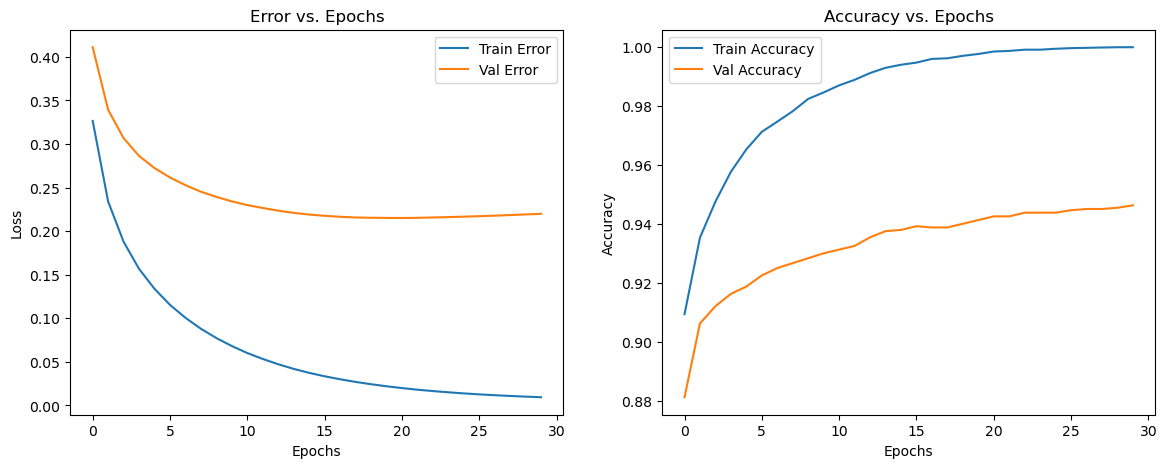

Test error: 0.1780856
Test accuracy: 94.1 %


In [14]:
##################################################
#Prepare MNIST data.
##################################################
num_classes = 10
X_train = (mnist_traindata.reshape(mnist_traindata.shape[0], -1)/255.0).astype(np.float32)
T_train = np.eye(num_classes, dtype=np.float32)[mnist_trainlabel]

X_test = (mnist_testdata.reshape(mnist_testdata.shape[0], -1)/255.0).astype(np.float32)
T_test = np.eye(num_classes, dtype=np.float32)[mnist_testlabel]

##################################################
#Define the architecture
##################################################

#Complete the below function to impliment ReLU activation function
def ReLu(inp):
  return np.maximum(0, inp)

#Complete the below function to impliment gradient of ReLU activation function
def gradReLu(inp):
  return (inp > 0).astype(np.float32)

#Complete the below function to impliment softmax activation function
def softmax(inp):
  exp_inp = np.exp(inp - np.max(inp, axis=1, keepdims=True))
  outp = exp_inp/np.sum(exp_inp, axis=1, keepdims=True)
  return outp

#Complete the below function to impliment forward propagation of data
def fwdPropagate(inputs, weights):
  #Inputs: input data, paramters of network
  W1, W2, W3 = weights

  A1 = inputs @ W1
  Z1 = ReLu(A1)
  A2 = Z1 @ W2
  Z2 = ReLu(A2)
  A3 = Z2 @ W3
  Z3 = softmax(A3)

  outps = [Z1, Z2, Z3]

  #Return the requires outputs, i.e., final output and intermediate activations
  return outps

#Complete the below function to compute the gradients
def computeGradients(inputs, targets, weights, activations):
  #Inputs: input data, targets, parameters of network, intermediate activations

  Z1, Z2, Z3 = activations
  W1, W2, W3 = weights

  #Compute the errors
  delta3 = Z3 - targets
  delta2 = gradReLu(Z2) * (delta3 @ W3.T)
  delta1 = gradReLu(Z1) * (delta2 @ W2.T)

  #Compute the derivative of loss at parameters
  dj_dw1 = inputs.T @ delta1
  dj_dw2 = Z1.T @ delta2 
  dj_dw3 = Z2.T @ delta3

  #Return the gradients
  return [dj_dw1, dj_dw2, dj_dw3]

def loss(T, Y):
    N = Y.shape[0]
    
    epsilon = 1e-15
    Y = np.clip(Y, epsilon, 1.0 - epsilon)
    
    loss = -np.sum(T * np.log(Y)) / N
    
    return loss

#Complete the below function to update the parameters using the above computed gradients
def applyGradients(weights, gradients, learning_rate):
  #Inputs: weights, gradients, and learning rate
  W1, W2, W3 = weights
  dj_dw1, dj_dw2, dj_dw3 = gradients

  W1 -= learning_rate*dj_dw1
  W2 -= learning_rate*dj_dw2
  W3 -= learning_rate*dj_dw3

  #Return the updated parameters
  return [W1, W2, W3]

#Complete the below function to complete the backpropagation ste
def backPropagate(inputs, targets, weights, activations, learning_rate):
  #Inputs: input data, targets, parameters of network, intermediate activations, learning rate of optimization algorithm

  #Compute the gradients
  gradients = computeGradients(inputs, targets, weights, activations)

  #Update the paramters using gradients
  weights = applyGradients(weights, gradients, learning_rate)

  #Return the updated parameters
  return weights

##################################################
#Train the network
##################################################

#Complete the below function to complete the training of network
def training(inputs, targets, batch_size = 128, epochs=30, train_val_split=0.8, learning_rate=0.001):
  #Set the hyperparameters
  hidden_units = [512, 512, 10]
  
  n_classes = num_classes
  n_samples = inputs.shape[0]
  n_batches = int(n_samples*train_val_split) // batch_size
  inp_dim = inputs.shape[1]

  #Split the training data into two parts.
  #Use 90 percent of training data for training the network.
  #Remaining 10 percent as validation data
  #Shuffling data
  indices = np.random.permutation(inputs.shape[0])
  X = inputs[indices]
  T = targets[indices]
  X_train = X[:int(train_val_split*n_samples)]
  T_train = T[:int(train_val_split*n_samples)]

  X_val = X[int(train_val_split*n_samples):]
  T_val = T[int(train_val_split*n_samples):]

  #Randomly initialize the weights
  W1 = (np.random.randn(hidden_units[0], inp_dim) * np.sqrt(2. / inp_dim)).astype(np.float32).T
  W2 = (np.random.randn(hidden_units[1], hidden_units[0]) * np.sqrt(2. / hidden_units[0])).astype(np.float32).T
  W3 = (np.random.randn(hidden_units[2], hidden_units[1]).astype(np.float32) * np.sqrt(2. / hidden_units[1])).astype(np.float32).T
  weights = [W1, W2, W3]

  train_acc_history, train_err_history = [], []
  val_acc_history, val_err_history = [], []

  # #Interate for epochs times
  for epoch in range(epochs):
    print(f"Training epoch #{epoch}")
    #Iterate through the batches of data
    for batch in range(n_batches):
      #Get the batch of data
      X_batch = X_train[batch*batch_size:(batch+1)*batch_size]
      T_batch = T_train[batch*batch_size:(batch+1)*batch_size]

      #Forward propagation
      activations = fwdPropagate(X_batch, weights)

      #Backward propagation
      weights = backPropagate(X_batch, T_batch, weights, activations, learning_rate)

    Y_train_ep = fwdPropagate(X_train, weights)[-1]
    train_acc_history.append((np.argmax(Y_train_ep, axis=1) == np.argmax(T_train, axis=1)).mean())
    train_err_history.append(loss(T_train, Y_train_ep))
    
    Y_val_ep = fwdPropagate(X_val, weights)[-1]
    val_acc_history.append((np.argmax(Y_val_ep, axis=1) == np.argmax(T_val, axis=1)).mean())
    val_err_history.append(loss(T_val, Y_val_ep))
      
  #Compute outputs on training data
  Y_train = fwdPropagate(X_train, weights)[-1]
  Y_train_labels = np.argmax(Y_train, axis=1)
  T_train_labels = np.argmax(T_train, axis=1)

  #Compute training accuracy, and training error
  train_acc = (Y_train_labels == T_train_labels).mean()
  train_err = loss(T_train, Y_train)

  #Compute outputs on validation data
  Y_val = fwdPropagate(X_val, weights)[-1]
  Y_val_labels = np.argmax(Y_val, axis=1)
  T_val_labels = np.argmax(T_val, axis=1)

  #Compute validation accuracy, and validation error
  val_acc = (Y_val_labels == T_val_labels).mean()
  val_err = loss(T_val, Y_val)

  #Print the statistics of training, i.e., training error, training accuracy, validation error, and validation accuracy
  print("Training error:", train_err)
  print("Training accuracy:", train_acc*100, "%")
  print("Validation error:", val_err)
  print("Validation accuracy:", val_acc*100, "%")

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
  ax1.plot(range(epochs), train_err_history, label='Train Error')
  ax1.plot(range(epochs), val_err_history, label='Val Error')
  ax1.set_title('Error vs. Epochs')
  ax1.set_xlabel('Epochs')
  ax1.set_ylabel('Loss')
  ax1.legend()

  ax2.plot(range(epochs), train_acc_history, label='Train Accuracy')
  ax2.plot(range(epochs), val_acc_history, label='Val Accuracy')
  ax2.set_title('Accuracy vs. Epochs')
  ax2.set_xlabel('Epochs')
  ax2.set_ylabel('Accuracy')
  ax2.legend()
  plt.show()

  #Save the parameters of network
  return weights

# Hyperparameters
batch_size=100
epochs=30
train_val_split=0.8
learning_rate=0.001

#Call the training function to train the network
weights = training(X_train, T_train, batch_size, epochs, train_val_split, learning_rate)

##################################################
#Evaluate the performance on test data
##################################################
#Compute outputs on test data
Y_test = fwdPropagate(X_test, weights)[-1]
Y_test_labels = np.argmax(Y_test, axis=1)
T_test_labels = np.argmax(T_test, axis=1)

#Compute test accuracy, and test error
test_acc = (Y_test_labels == T_test_labels).mean()
test_err = loss(T_test, Y_test)
print("Test error:", test_err)
print("Test accuracy:", test_acc*100, "%")

<b> Report your observations </b>

1. The test accuracy of 94.1% compared to the near-perfect 99.9791% training score shows that the model has overfit the training data in the given 30 epochs.

2. Training error gradually goes down to about 0.00937 and is monotonically decreasing, but the validation error has a dip at the 20th epoch and then a little upward drift in the error signifying the slight overfit model. This is a classic sign that the model has stopped learning general features of digits and has started memorizing the specific noise or "quirks" in the training dataset. Early stopping may resolve this problem.

3. With 512 nodes in two hidden layers, there is a lot of parameters for only 10,000 training samples. This high parameter-to-data ratio is likely why the training accuracy hit 99.9% so easily. The network essentially has enough parameters to store almost every feature  of every individual image rather than learning the geometry of a '4' or an '8'.

4. The validation accuract curve is a bit jittery as number of epochs increase, due to SGD and it's stochastic oscillatory nature.

